# CA$^{2}$Point Demo

In this notebook we extract keypoints and descriptors from two pairs of images and match them using the mutual nearest neighbor method.

In [1]:
import torch
from pathlib import Path
import numpy as np

from ca2point.extractor import CA2PointExtractor
from ca2point.matcher import MNNMatcher
from ca2point.utils import read_image
from ca2point import visual

images_path = Path("assets")

## Feature extractor and matcher

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

extractor = CA2PointExtractor()
matcher = MNNMatcher()

## Illumination change example
The top images show the keypoints extracted by our proposed CA$^2$Point, while the bottom images show the matches between the two images. In this case, CA$^{2}$Point can avoid extracting keypoints in unreliable areas such as the sky.

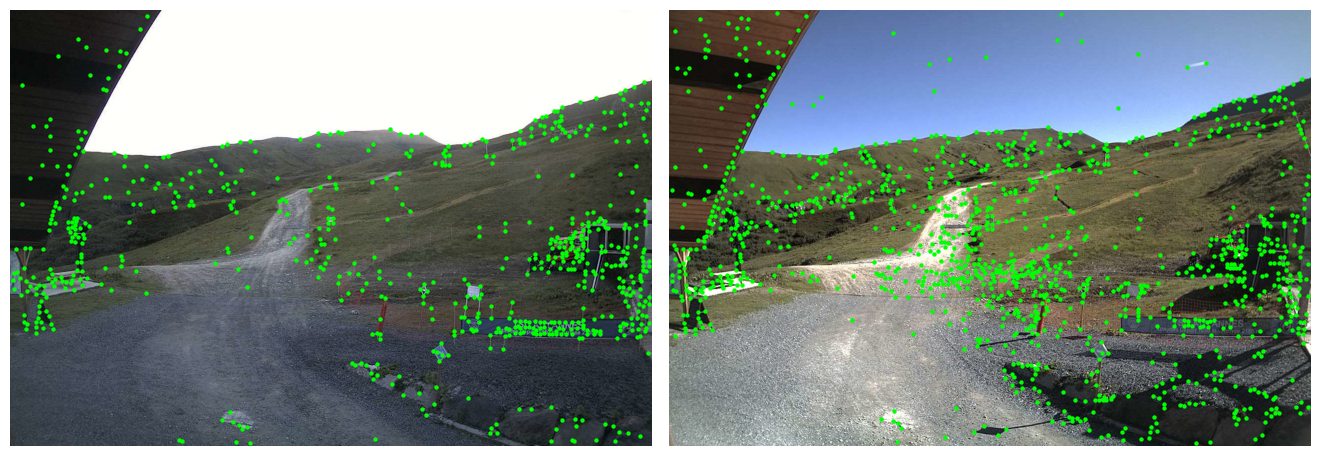

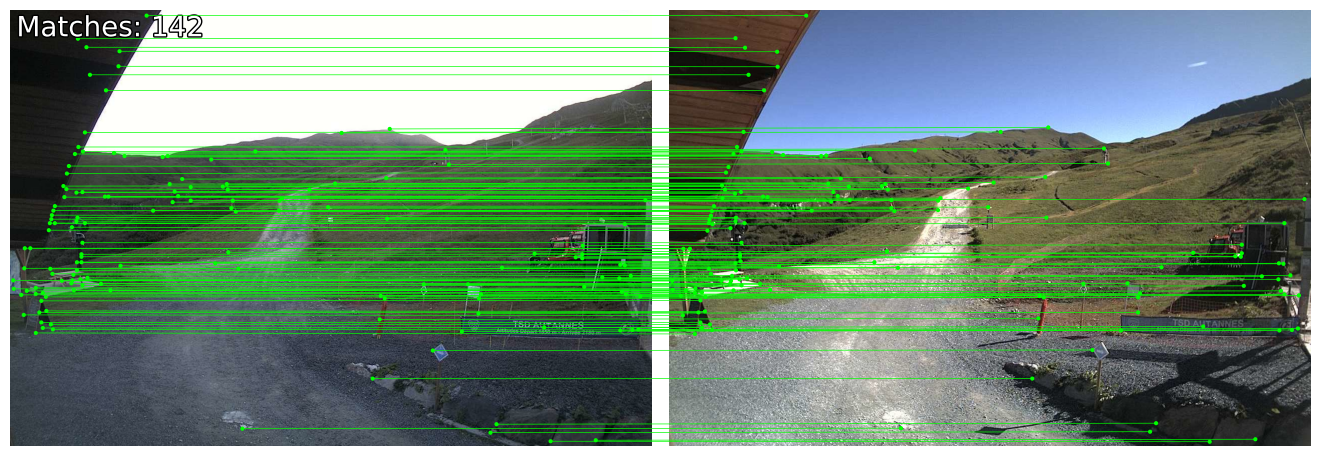

In [3]:
image0 = read_image(images_path / "i_autannes/1.ppm")
image1 = read_image(images_path / "i_autannes/4.ppm")

keypoints_0, descriptors_0, scores_0 = extractor.extract(image0)
keypoints_1, descriptors_1, scores_1 = extractor.extract(image1)

gt_homography = torch.from_numpy(np.loadtxt(str(images_path / "i_autannes/H_1_4")))
matches = matcher.match(descriptors_0, descriptors_1, keypoints_0, keypoints_1, gt_homography)
m_keypoints0, m_keypoints1 = keypoints_0[matches[..., 0]], keypoints_1[matches[..., 1]]

axes = visual.plot_images([image0, image1])
visual.plot_keypoints([keypoints_0, keypoints_1], ps=10)

visual.plot_images([image0, image1])
visual.plot_matches(m_keypoints0, m_keypoints1, color="lime", lw=0.5)
visual.add_text(0, f'Matches: {len(matches)}', fs=20)

## Viewpoint change example
For pairs with significant viewpoint changes, CA$^{2}$2Point can extract more keypoints and obtain more correct matches with only MNN matcher.

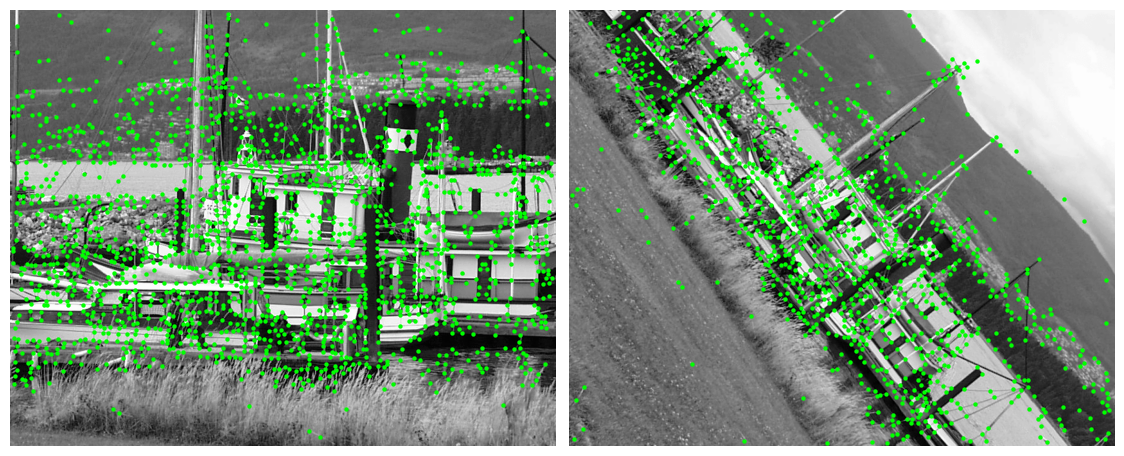

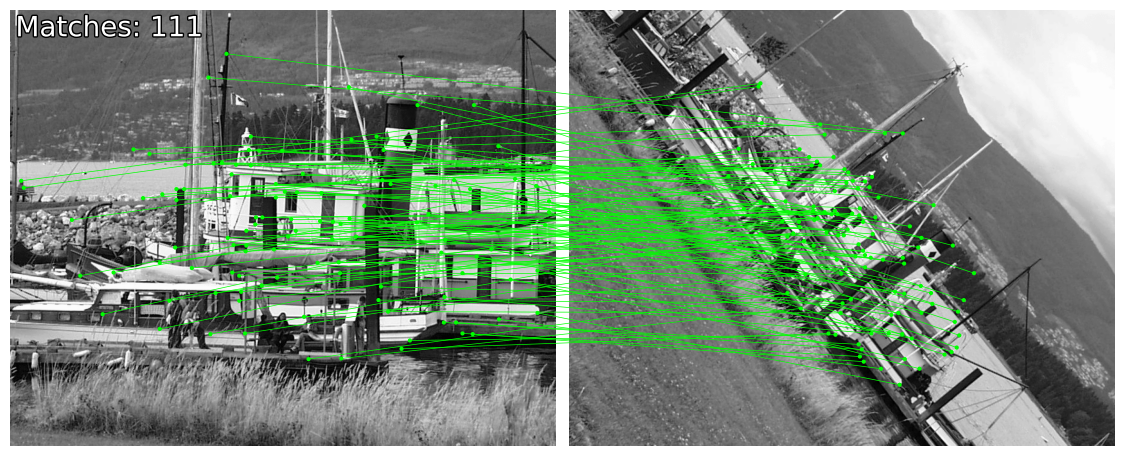

In [4]:
image0 = read_image(images_path / "v_boat/1.ppm")
image1 = read_image(images_path / "v_boat/4.ppm")

keypoints_0, descriptors_0, _ = extractor.extract(image0)
keypoints_1, descriptors_1, _ = extractor.extract(image1)

gt_homography = torch.from_numpy(np.loadtxt(str(images_path / "v_boat/H_1_4")))
matches = matcher.match(descriptors_0, descriptors_1, keypoints_0, keypoints_1, gt_homography)
m_keypoints0, m_keypoints1 = keypoints_0[matches[..., 0]], keypoints_1[matches[..., 1]]

axes = visual.plot_images([image0, image1])
visual.plot_keypoints([keypoints_0, keypoints_1], ps=10)

visual.plot_images([image0, image1])
visual.plot_matches(m_keypoints0, m_keypoints1, color="lime", lw=0.5)
visual.add_text(0, f'Matches: {len(matches)}', fs=20)